In [1]:
import numpy as numpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('Writing_style.csv')
df

,timestamp,words,time,f05,err,gleu,grade_level,language,style,model
0,10/16/2025 15:44,64,1.29,0.572,30.16%,0.241,8,English,Casual,mistral
1,10/16/2025 15:45,64,11.16,0.572,30.16%,0.224,8,English,Casual,deepseek-r1:7b
2,10/16/2025 15:45,64,5.70,0.568,28.57%,0.259,7,English,Casual,llama3.2
3,10/16/2025 15:45,64,1.63,0.568,28.57%,0.259,7,English,Casual,gemma3
4,10/16/2025 15:45,117,4.48,0.575,28.45%,0.297,14,English,Academic,llama3.2
5,10/16/2025 15:46,117,2.36,0.581,30.17%,0.321,14,English,Academic,mistral
6,10/16/2025 15:46,117,16.48,0.602,39.66%,0.215,14,English,Academic,deepseek-r1:7b
7,10/16/2025 15:46,117,6.68,0.532,23.28%,0.381,14,English,Academic,gemma3
8,10/16/2025 15:46,137,2.69,0.412,13.24%,0.541,17,English,Formal,gemma3
9,10/16/2025 15:46,137,4.71,0.473,16.91%,0.485,17,English,Formal,llama3.2


In [3]:
import pandas as pd
import numpy as np
from faker import Faker

df["err"] = df["err"].str.replace("%", "").astype(float)

# --- Parameters ---
k = 5          # desired anonymity level
target_size = 100  # total synthetic records
fake = Faker()

# --- Identify quasi-identifiers and numeric columns ---
quasi_cols = ["style", "model", "grade_level"]
num_cols = ["words", "time", "f05", "err", "gleu"]

# --- Create synthetic base by sampling combinations ensuring ≥k per group ---
groups = df.groupby(quasi_cols)
synthetic_data = []

while len(synthetic_data) < target_size:
    for name, group in groups:
        # draw k samples (with replacement)
        sampled = group.sample(n=k, replace=True).copy()
        
        # add slight noise to numeric values to avoid identical rows
        for col in num_cols:
            std = group[col].std() if group[col].std() > 0 else 0.1
            sampled[col] = sampled[col] + np.random.normal(0, std * 0.5, len(sampled))
        
        # randomize timestamps a bit
        sampled["timestamp"] = pd.to_datetime(group["timestamp"].sample(1).values[0]) \
                               + pd.to_timedelta(np.random.randint(0, 10000, len(sampled)), unit="s")
        
        # randomize language to mimic diversity
        sampled["language"] = np.random.choice(["English", "Spanish", "French"], len(sampled), p=[0.9, 0.05, 0.05])
        
        synthetic_data.append(sampled)
        if len(pd.concat(synthetic_data)) >= target_size:
            break

# --- Combine & trim to target size ---
synthetic_df = pd.concat(synthetic_data).head(target_size).reset_index(drop=True)

# --- Round and format values ---
synthetic_df["err"] = synthetic_df["err"].clip(lower=0).round(2)
synthetic_df["gleu"] = synthetic_df["gleu"].clip(0, 1).round(3)
synthetic_df["f05"] = synthetic_df["f05"].clip(0, 1).round(3)
synthetic_df["time"] = synthetic_df["time"].clip(lower=0).round(2)
synthetic_df["words"] = synthetic_df["words"].astype(int)
synthetic_df["err"] = synthetic_df["err"].astype(float)
# --- Reapply % for readability ---
filtered_df = synthetic_df.drop(columns=["timestamp", "language", "words", "time"])
print(filtered_df.head(10))
filtered_df.to_csv("synthetic_k_anon_data.csv", index=False)


     f05    err   gleu  grade_level     style           model
0  0.594  39.66  0.214           14  Academic  deepseek-r1:7b
1  0.571  39.64  0.212           14  Academic  deepseek-r1:7b
2  0.645  39.71  0.264           14  Academic  deepseek-r1:7b
3  0.610  39.77  0.211           14  Academic  deepseek-r1:7b
4  0.598  39.67  0.270           14  Academic  deepseek-r1:7b
5  0.615  23.26  0.384           14  Academic          gemma3
6  0.522  23.33  0.309           14  Academic          gemma3
7  0.571  23.29  0.441           14  Academic          gemma3
8  0.569  23.27  0.340           14  Academic          gemma3
9  0.481  23.27  0.410           14  Academic          gemma3


C:\Users\jahed\AppData\Local\Temp\ipykernel_39352\2355998864.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\jahed\AppData\Local\Temp\ipykernel_39352\2355998864.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\jahed\AppData\Local\Temp\ipykernel_39352\2355998864.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\jahed\AppData\Local\Temp\ipykernel_39352\2355998864.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

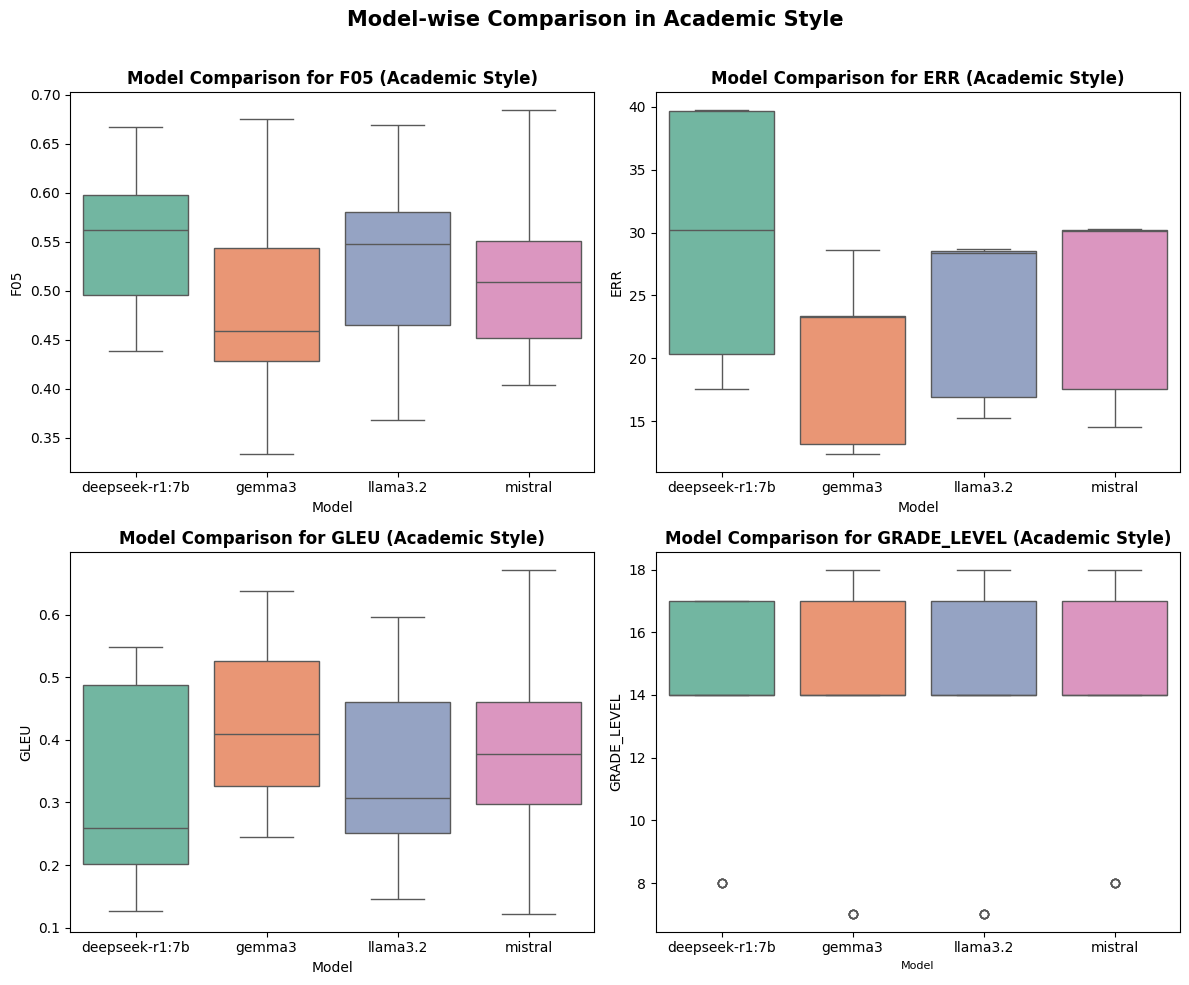

In [4]:
metrics = ["f05", "err", "gleu", "grade_level"]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    sns.boxplot(
        data=filtered_df, x="model", y=metric, palette="Set2", ax=axes[i]
    )
    axes[i].set_title(f"Model Comparison for {metric.upper()} (Academic Style)", fontsize=12, weight="bold")
    axes[i].set_xlabel("Model")
    axes[i].set_ylabel(metric.upper())

plt.suptitle("Model-wise Comparison in Academic Style", fontsize=15, weight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.xlabel("Model", fontsize=8)
plt.show()


C:\Users\jahed\AppData\Local\Temp\ipykernel_39352\3390490487.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\jahed\AppData\Local\Temp\ipykernel_39352\3390490487.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\jahed\AppData\Local\Temp\ipykernel_39352\3390490487.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\jahed\AppData\Local\Temp\ipykernel_39352\3390490487.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `h

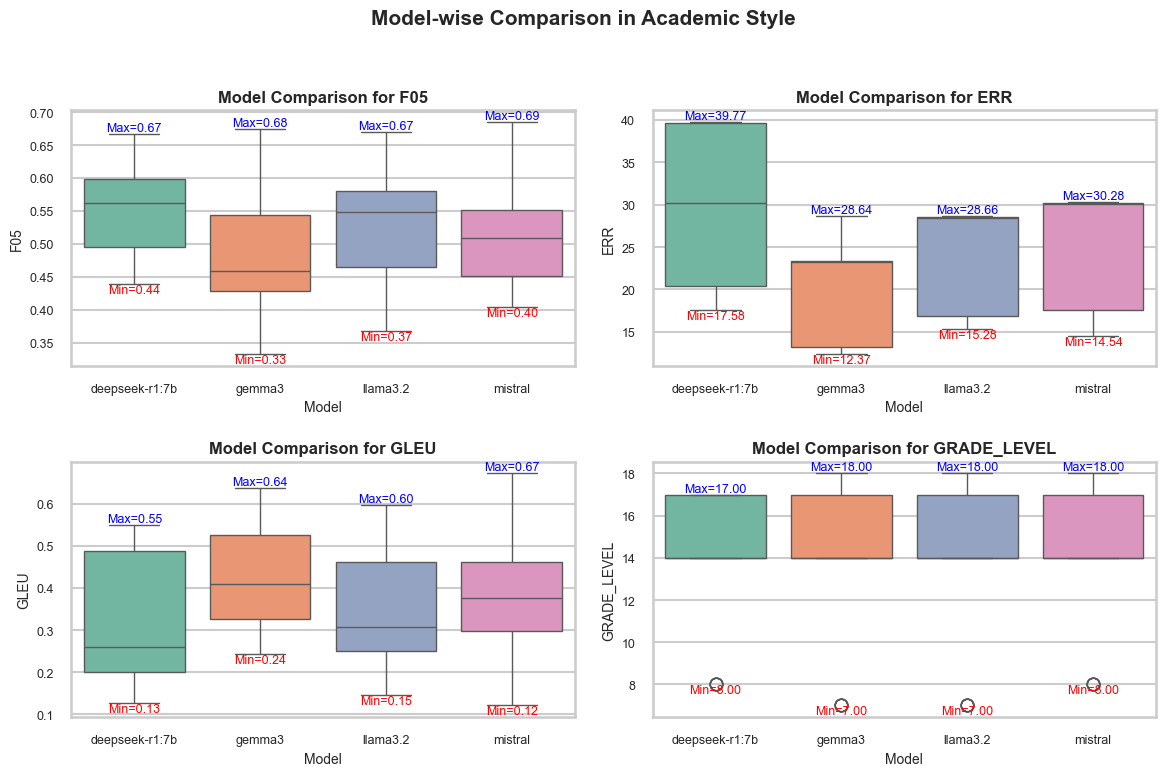

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Example settings
metrics = ["f05", "err", "gleu", "grade_level"]
font_size = 9   # controls annotation and tick label size

sns.set(style="whitegrid", context="talk")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    sns.boxplot(
        data=filtered_df, x="model", y=metric, palette="Set2", ax=axes[i]
    )
    axes[i].set_title(f"Model Comparison for {metric.upper()}",
                      fontsize=12, weight="bold")
    axes[i].set_xlabel("Model", fontsize=10)
    axes[i].set_ylabel(metric.upper(), fontsize=10)

    # --- Add min and max annotations ---
    for model in filtered_df["model"].unique():
        sub = filtered_df[filtered_df["model"] == model][metric].dropna()
        if len(sub) > 0:
            ymin, ymax = sub.min(), sub.max()
            xpos = list(filtered_df["model"].unique()).index(model)
            axes[i].text(xpos, ymin, f"Min={ymin:.2f}",
                         ha='center', va='top',
                         fontsize=font_size, color='red')
            axes[i].text(xpos, ymax, f"Max={ymax:.2f}",
                         ha='center', va='bottom',
                         fontsize=font_size, color='blue')

    # ✅ Apply tick label sizes only (no font family)
    axes[i].tick_params(axis='x', labelsize=font_size)
    axes[i].tick_params(axis='y', labelsize=font_size)

plt.suptitle("Model-wise Comparison in Academic Style",
             fontsize=15, weight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


C:\Users\jahed\AppData\Local\Temp\ipykernel_39352\2961822812.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\jahed\AppData\Local\Temp\ipykernel_39352\2961822812.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\jahed\AppData\Local\Temp\ipykernel_39352\2961822812.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\jahed\AppData\Local\Temp\ipykernel_39352\2961822812.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `h

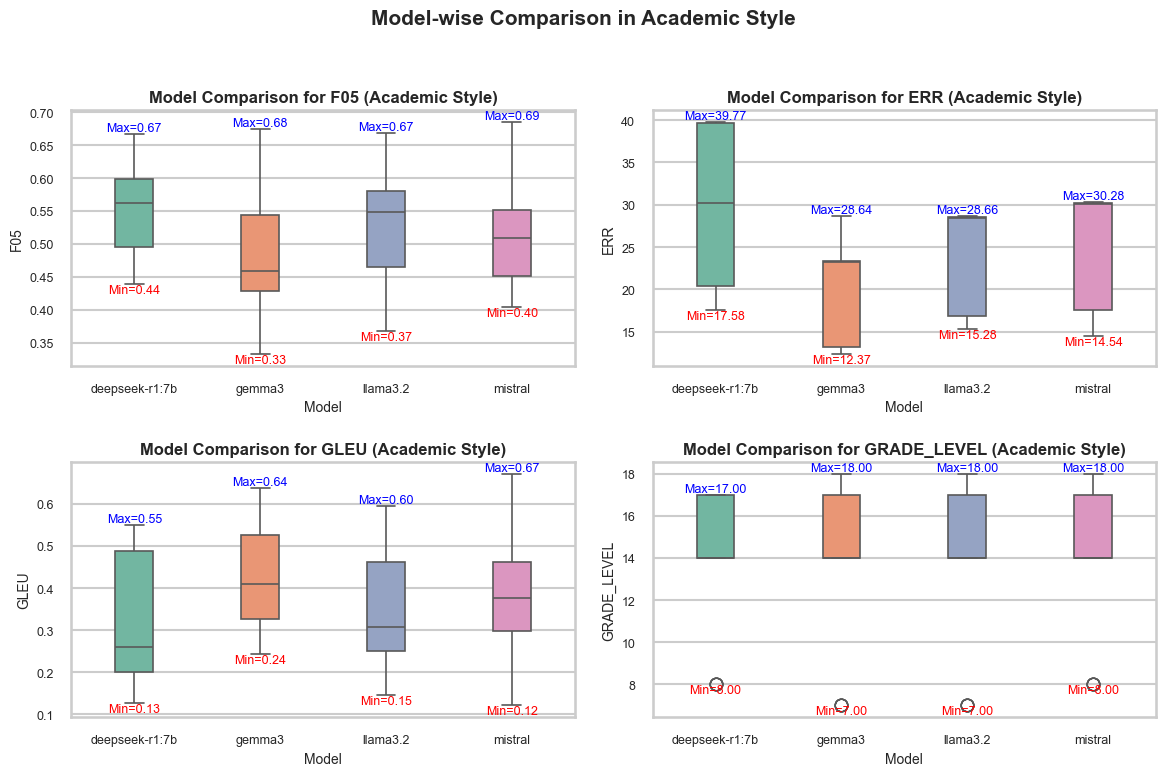

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Example settings
metrics = ["f05", "err", "gleu", "grade_level"]
font_size = 9           # controls annotation and tick label size
box_width = 0.3        # controls how wide each box appears (default ≈ 0.8 in seaborn)
box_linewidth = 1.2     # thickness of box borders

sns.set(style="whitegrid", context="talk")

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    sns.boxplot(
        data=filtered_df,
        x="model",
        y=metric,
        palette="Set2",
        ax=axes[i],
        width=box_width,        # ✅ control box width here
        linewidth=box_linewidth # ✅ control box outline thickness
    )

    axes[i].set_title(f"Model Comparison for {metric.upper()} (Academic Style)",
                      fontsize=12, weight="bold")
    axes[i].set_xlabel("Model", fontsize=10)
    axes[i].set_ylabel(metric.upper(), fontsize=10)

    # --- Add min and max annotations ---
    for model in filtered_df["model"].unique():
        sub = filtered_df[filtered_df["model"] == model][metric].dropna()
        if len(sub) > 0:
            ymin, ymax = sub.min(), sub.max()
            xpos = list(filtered_df["model"].unique()).index(model)
            axes[i].text(xpos, ymin, f"Min={ymin:.2f}",
                         ha='center', va='top',
                         fontsize=font_size, color='red')
            axes[i].text(xpos, ymax, f"Max={ymax:.2f}",
                         ha='center', va='bottom',
                         fontsize=font_size, color='blue')

    # ✅ Apply tick label sizes only (no font family)
    axes[i].tick_params(axis='x', labelsize=font_size)
    axes[i].tick_params(axis='y', labelsize=font_size)

plt.suptitle("Model-wise Comparison in Academic Style",
             fontsize=15, weight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


C:\Users\jahed\AppData\Local\Temp\ipykernel_39352\3950924981.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\jahed\AppData\Local\Temp\ipykernel_39352\3950924981.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\jahed\AppData\Local\Temp\ipykernel_39352\3950924981.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\jahed\AppData\Local\Temp\ipykernel_39352\3950924981.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `h

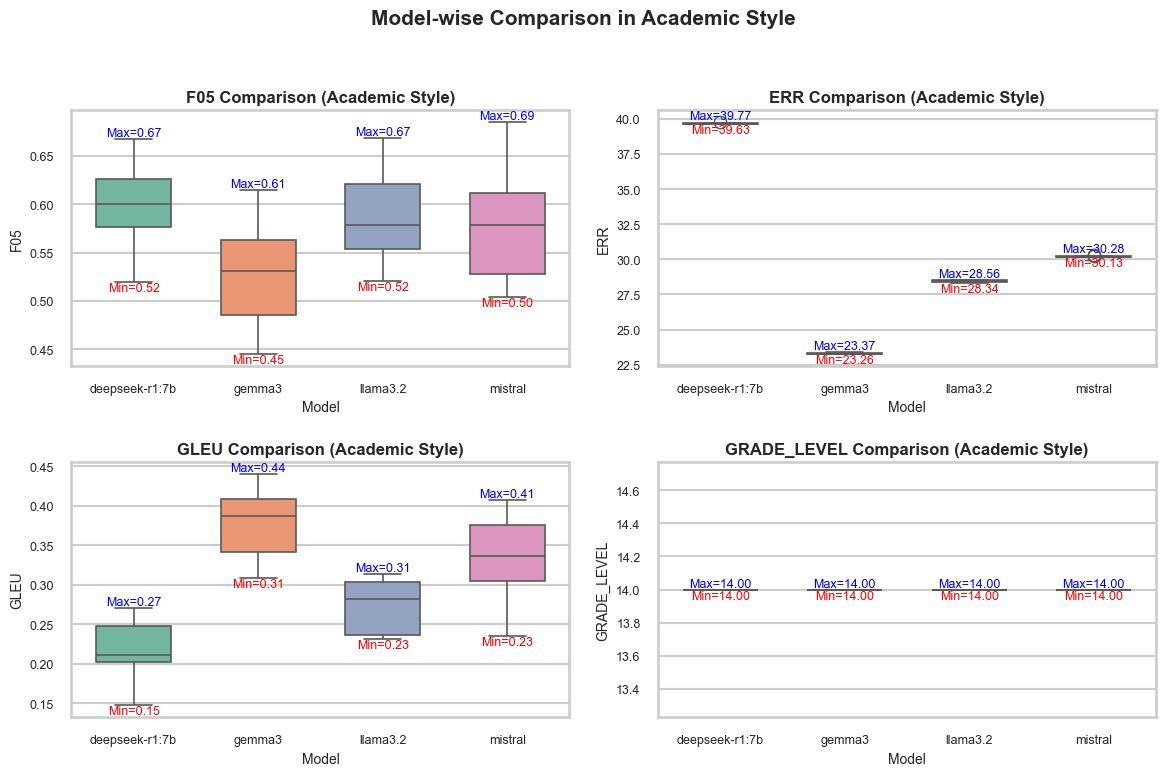

C:\Users\jahed\AppData\Local\Temp\ipykernel_39352\3950924981.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\jahed\AppData\Local\Temp\ipykernel_39352\3950924981.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\jahed\AppData\Local\Temp\ipykernel_39352\3950924981.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\jahed\AppData\Local\Temp\ipykernel_39352\3950924981.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `h

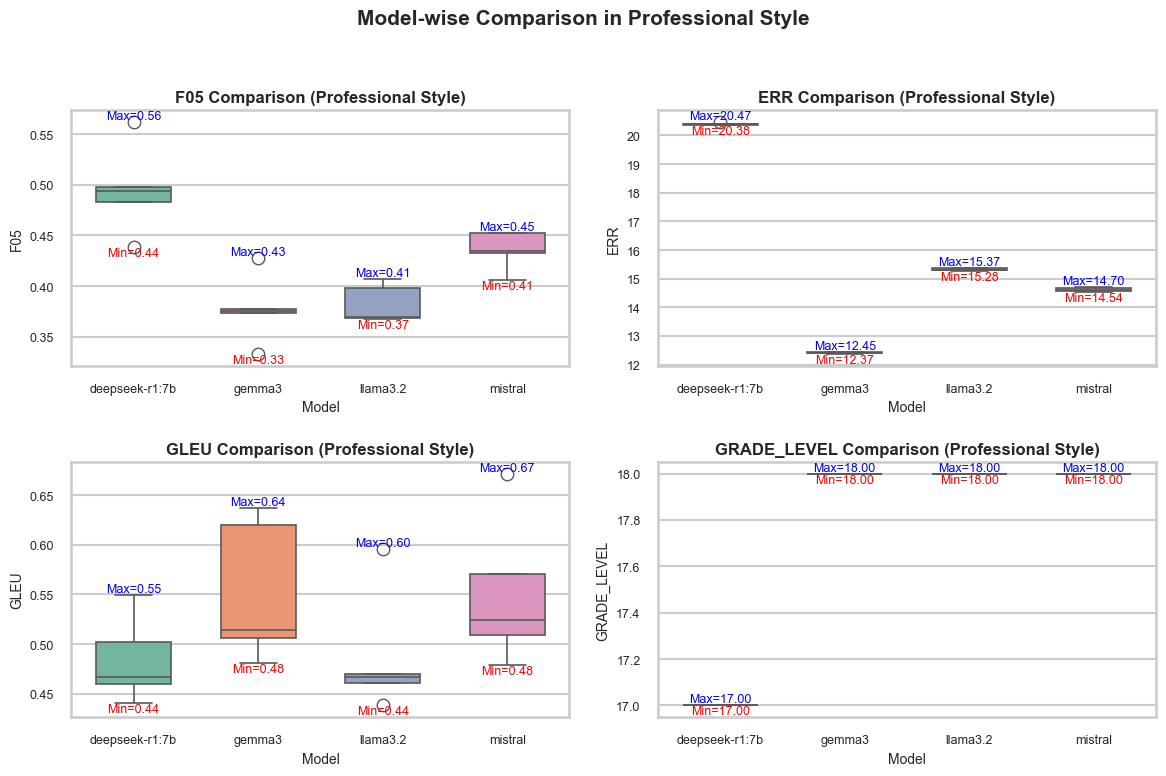

C:\Users\jahed\AppData\Local\Temp\ipykernel_39352\3950924981.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\jahed\AppData\Local\Temp\ipykernel_39352\3950924981.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\jahed\AppData\Local\Temp\ipykernel_39352\3950924981.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\jahed\AppData\Local\Temp\ipykernel_39352\3950924981.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `h

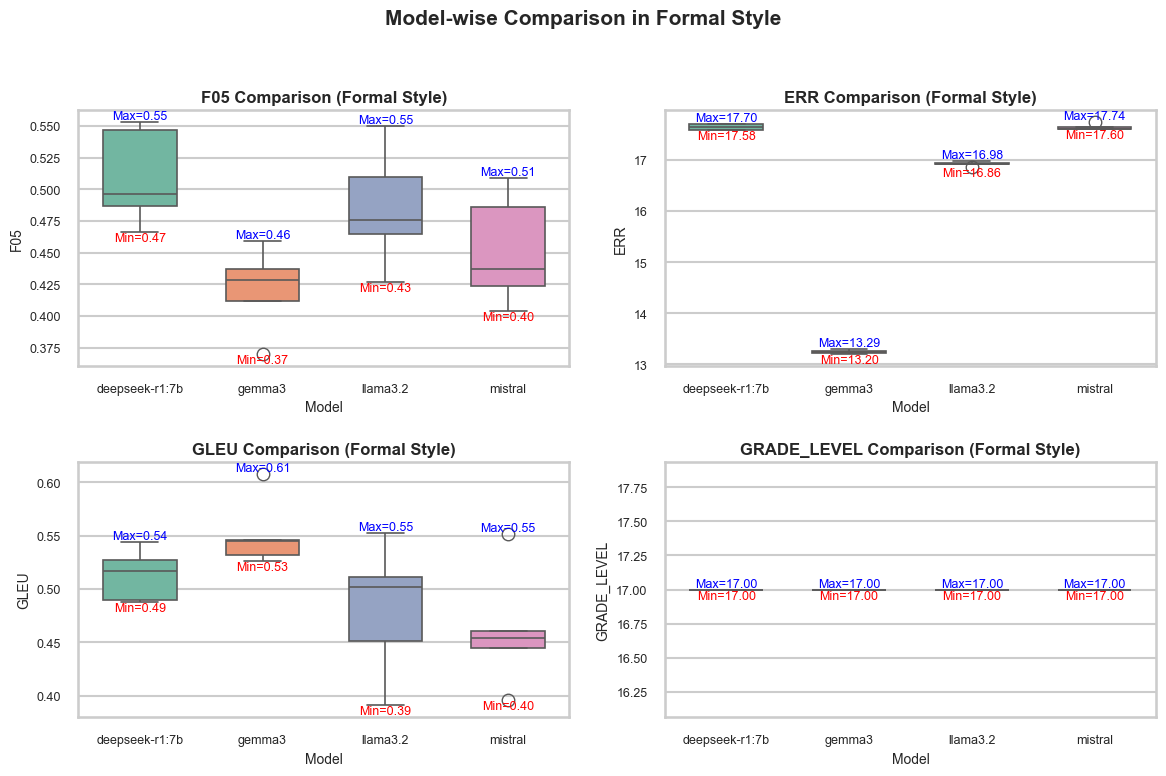

C:\Users\jahed\AppData\Local\Temp\ipykernel_39352\3950924981.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\jahed\AppData\Local\Temp\ipykernel_39352\3950924981.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\jahed\AppData\Local\Temp\ipykernel_39352\3950924981.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\jahed\AppData\Local\Temp\ipykernel_39352\3950924981.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `h

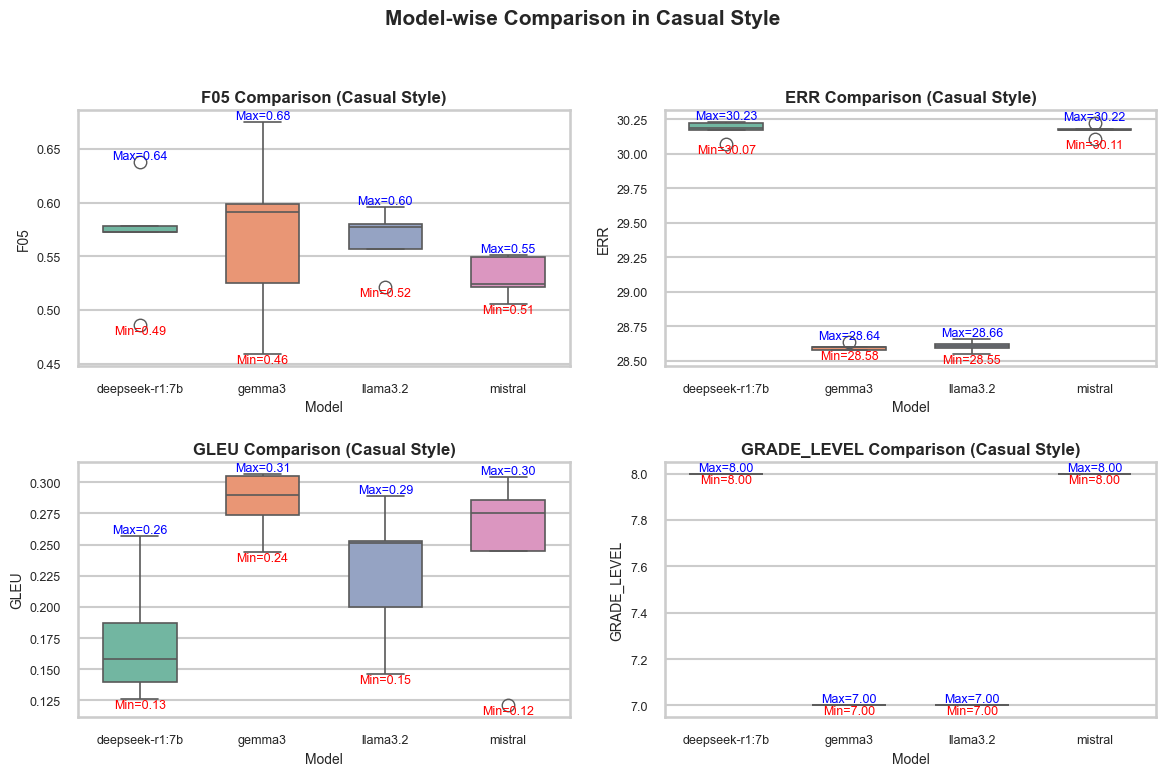

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Settings ---
metrics = ["f05", "err", "gleu", "grade_level"]
font_size = 9
box_width = 0.6
box_linewidth = 1.2
styles_to_plot = ["Academic", "Professional", "Formal", "Casual"]  # styles to generate plots for

sns.set(style="whitegrid", context="talk")

# --- Loop through each style ---
for style_name in styles_to_plot:
    subset = filtered_df[filtered_df["style"] == style_name]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    for i, metric in enumerate(metrics):
        sns.boxplot(
            data=subset,
            x="model",
            y=metric,
            palette="Set2",
            ax=axes[i],
            width=box_width,
            linewidth=box_linewidth
        )

        axes[i].set_title(f"{metric.upper()} Comparison ({style_name} Style)",
                          fontsize=12, weight="bold")
        axes[i].set_xlabel("Model", fontsize=10)
        axes[i].set_ylabel(metric.upper(), fontsize=10)

        # --- Add min and max annotations ---
        for model in subset["model"].unique():
            sub = subset[subset["model"] == model][metric].dropna()
            if len(sub) > 0:
                ymin, ymax = sub.min(), sub.max()
                xpos = list(subset["model"].unique()).index(model)
                axes[i].text(xpos, ymin, f"Min={ymin:.2f}",
                             ha='center', va='top',
                             fontsize=font_size, color='red')
                axes[i].text(xpos, ymax, f"Max={ymax:.2f}",
                             ha='center', va='bottom',
                             fontsize=font_size, color='blue')

        # ✅ Apply tick label size
        axes[i].tick_params(axis='x', labelsize=font_size)
        axes[i].tick_params(axis='y', labelsize=font_size)

    # --- Title per style ---
    plt.suptitle(f"Model-wise Comparison in {style_name} Style",
                 fontsize=15, weight="bold")

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


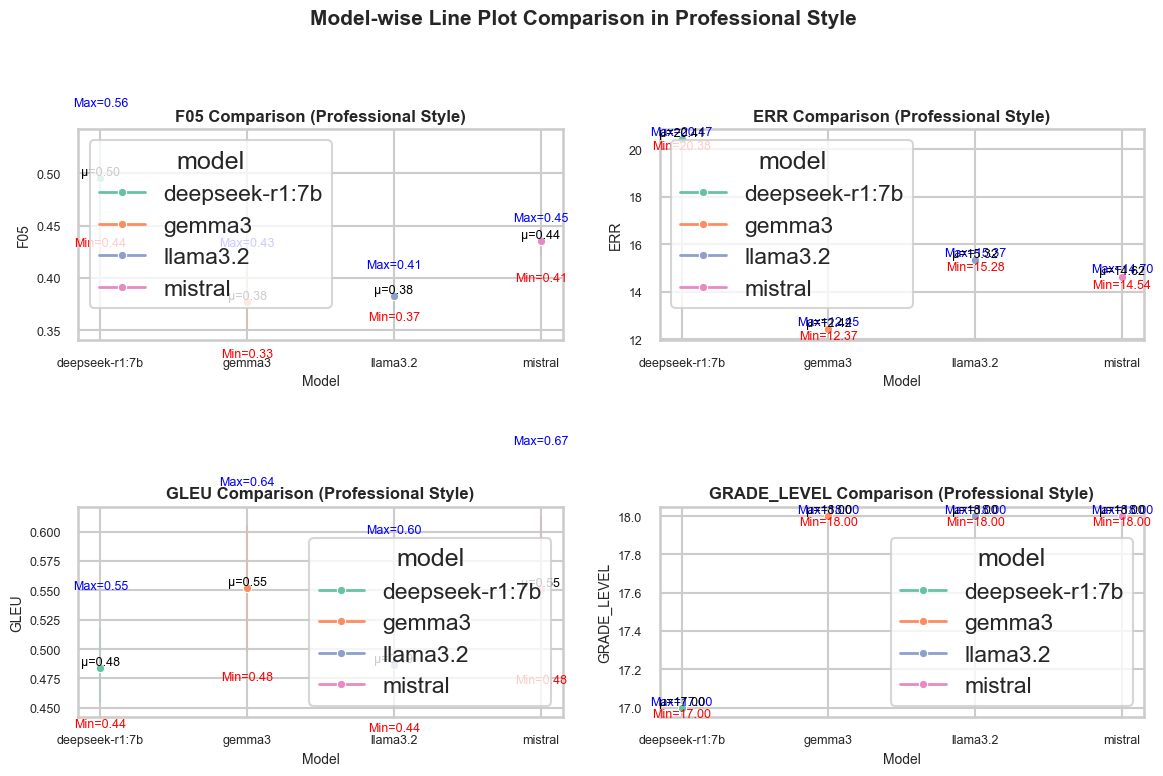

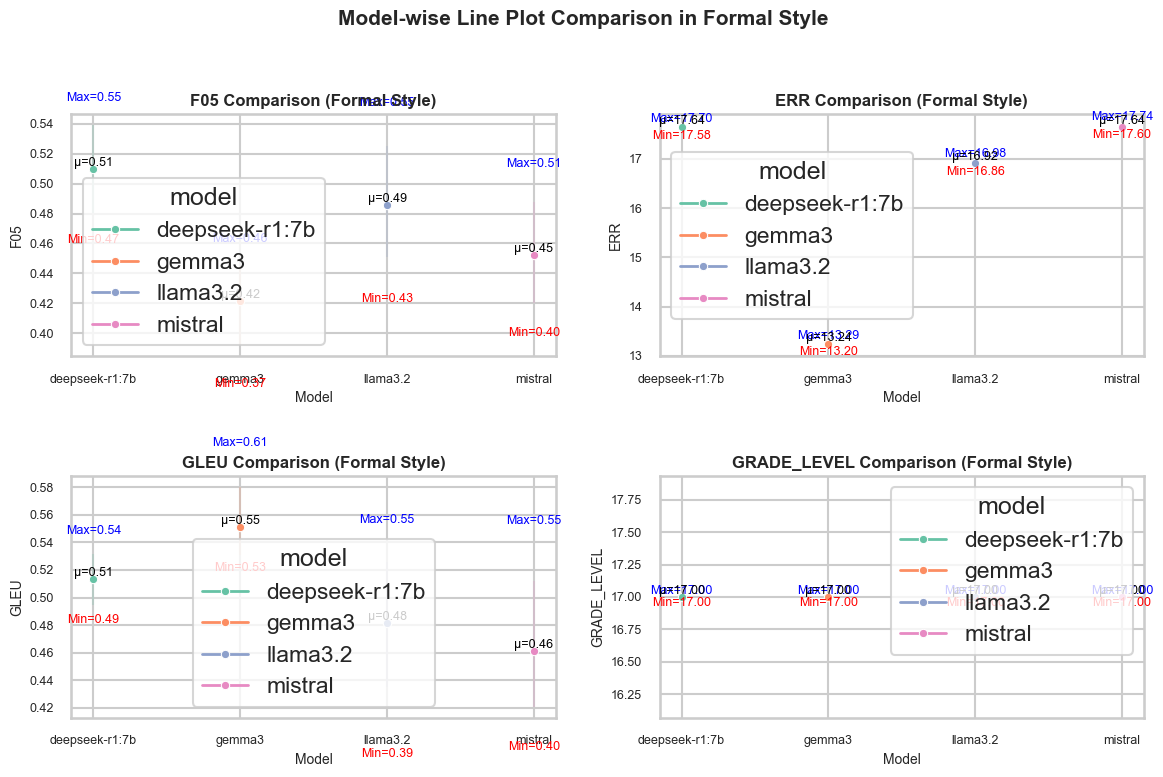

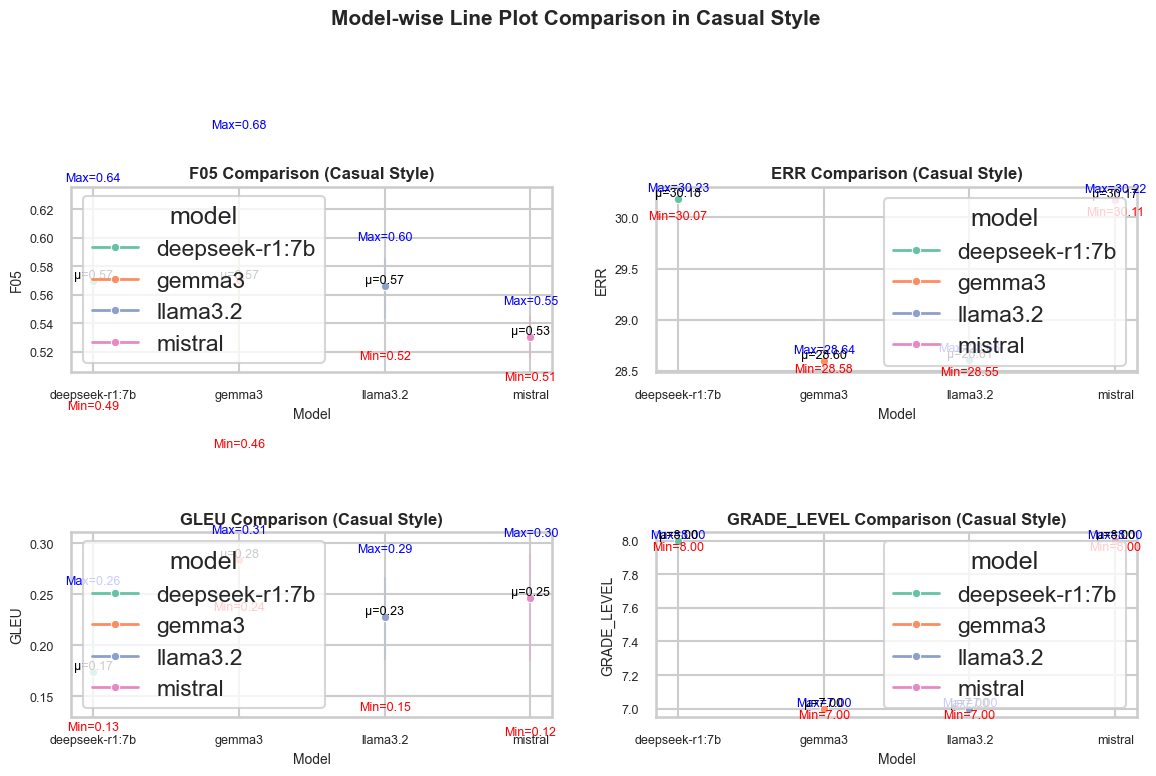

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Settings ---
metrics = ["f05", "err", "gleu", "grade_level"]
font_size = 9
line_width = 2
marker_size = 6
styles_to_plot = ["Professional", "Formal", "Casual"]  # styles to plot

sns.set(style="whitegrid", context="talk")

# --- Loop through each style ---
for style_name in styles_to_plot:
    subset = filtered_df[filtered_df["style"] == style_name]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    for i, metric in enumerate(metrics):
        sns.lineplot(
            data=subset,
            x="model",
            y=metric,
            hue="model",
            marker="o",
            linewidth=line_width,
            markersize=marker_size,
            palette="Set2",
            ax=axes[i]
        )

        axes[i].set_title(f"{metric.upper()} Comparison ({style_name} Style)",
                          fontsize=12, weight="bold")
        axes[i].set_xlabel("Model", fontsize=10)
        axes[i].set_ylabel(metric.upper(), fontsize=10)

        # --- Add min and max annotations ---
        for model in subset["model"].unique():
            sub = subset[subset["model"] == model][metric].dropna()
            if len(sub) > 0:
                ymin, ymax = sub.min(), sub.max()
                ymean = sub.mean()
                xpos = list(subset["model"].unique()).index(model)
                axes[i].text(xpos, ymin, f"Min={ymin:.2f}",
                             ha='center', va='top',
                             fontsize=font_size, color='red')
                axes[i].text(xpos, ymax, f"Max={ymax:.2f}",
                             ha='center', va='bottom',
                             fontsize=font_size, color='blue')
                axes[i].text(xpos, ymean, f"μ={ymean:.2f}",
                             ha='center', va='bottom',
                             fontsize=font_size, color='black')

        # ✅ Apply tick label size
        axes[i].tick_params(axis='x', labelsize=font_size)
        axes[i].tick_params(axis='y', labelsize=font_size)

    # --- Title per style ---
    plt.suptitle(f"Model-wise Line Plot Comparison in {style_name} Style",
                 fontsize=15, weight="bold")

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


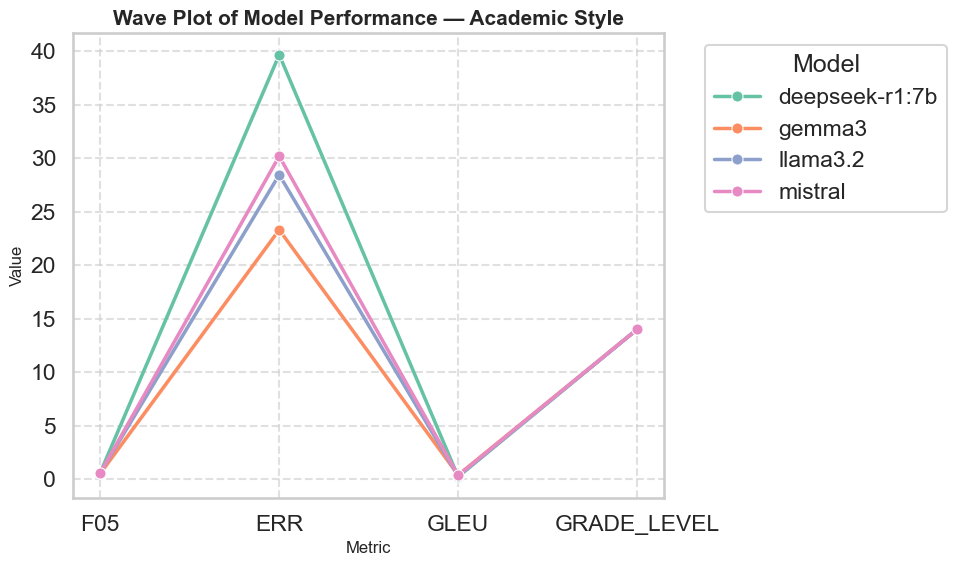

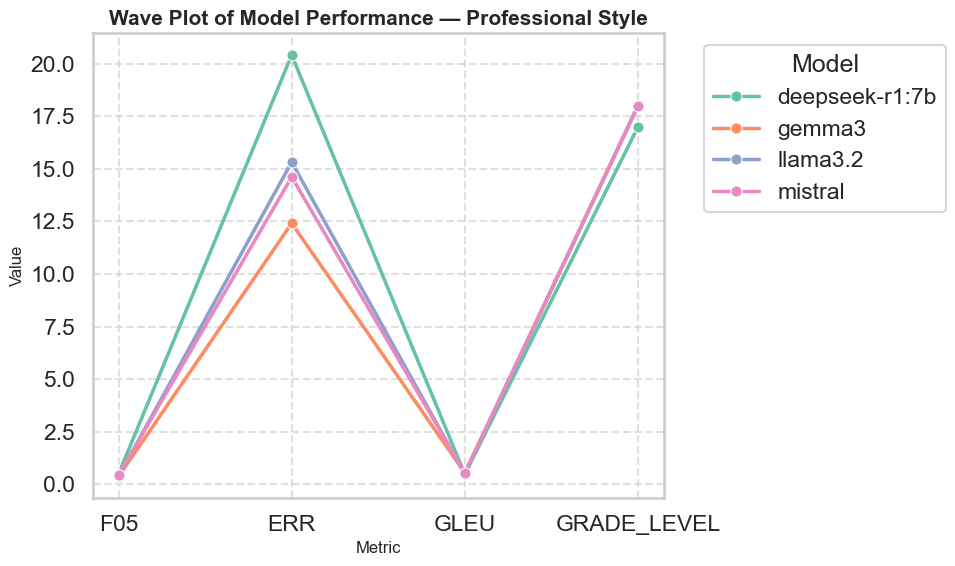

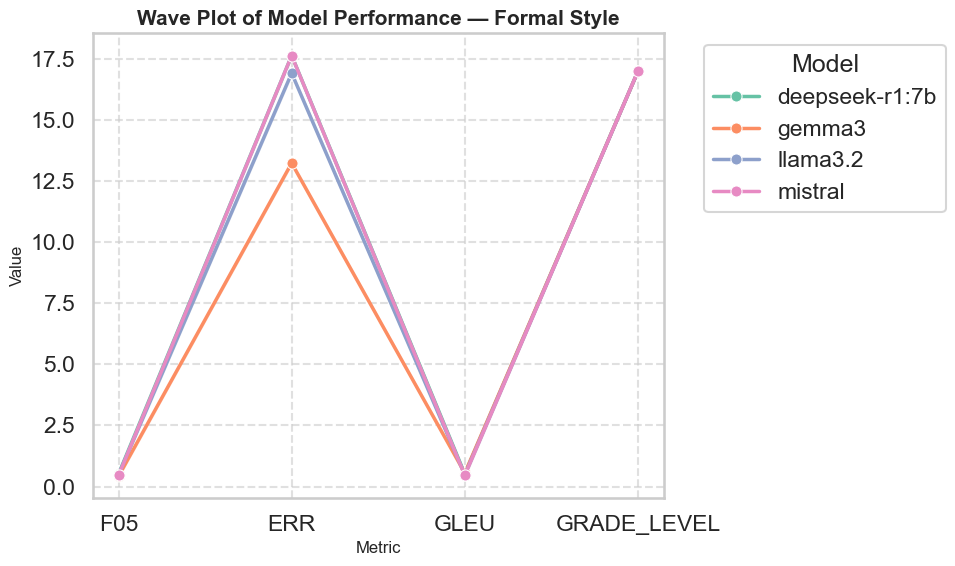

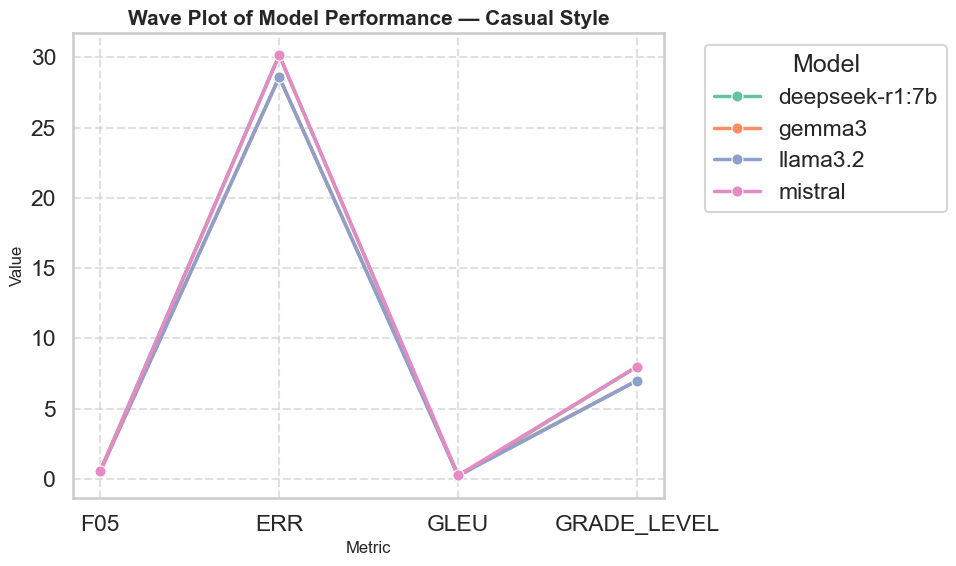

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Define metrics to visualize
metrics = ["f05", "err", "gleu", "grade_level"]
styles_to_plot = ["Academic", "Professional", "Formal", "Casual"]

sns.set(style="whitegrid", context="talk")

# --- Create a connected wave plot for each style ---
for style_name in styles_to_plot:
    subset = filtered_df[filtered_df["style"] == style_name]

    # Melt metrics for continuous plotting across them
    melted = subset.melt(id_vars=["model"], value_vars=metrics,
                         var_name="Metric", value_name="Value")

    plt.figure(figsize=(10, 6))
    sns.lineplot(
        data=melted,
        x="Metric",
        y="Value",
        hue="model",
        marker="o",
        linewidth=2.5,
        markersize=8,
        palette="Set2",
    )

    # Title and labels
    plt.title(f"Wave Plot of Model Performance — {style_name} Style",
              fontsize=15, weight="bold")
    plt.xlabel("Metric", fontsize=12)
    plt.ylabel("Value", fontsize=12)
    plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle="--", alpha=0.6)

    # Smooth "wave" look: ensure ordered metric axis
    plt.xticks(ticks=range(len(metrics)), labels=[m.upper() for m in metrics])
    
    plt.tight_layout()
    plt.show()
